# Bayesian Networks using Python (pgmpy)

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand Bayesian networks structure and semantics
- Build Bayesian networks in Python (a small pure-Python implementation that always runs, plus the equivalent pgmpy code for when that library is installed)
- Implement exact inference by enumeration
- Apply Bayesian networks to real-world decision-making problems

## 🔗 Where this fits

**Builds on:** Course 02 — Unit 3, lesson 01 "Learning under Uncertainty" — one Bayes update becomes a whole graph of them.

**Used later in:** Course 04 (AIAT 114) — Unit 3, where Naive Bayes is the simplest such network put to work as a classifier.

---

This notebook covers practical activities from **Course 02, Unit 3**:
- Building Bayesian networks in Python (pure-Python implementation, with the pgmpy library API shown alongside)
- Implementing inference algorithms for Bayesian networks (inference by enumeration)

---

## Introduction to Bayesian Networks

**Bayesian Networks** are probabilistic graphical models that represent conditional dependencies among variables using directed acyclic graphs (DAGs).


## 🌍 The case: two networks that shipped

**Xbox Live, from 2005.** **TrueSkill** — Herbrich, Minka & Graepel, *TrueSkill™: A Bayesian Skill Rating System* (NIPS 2006) — treats every player's skill as a hidden variable with a *distribution*, not a number: a mean and an uncertainty. Match results are the evidence; the posterior is updated by approximate message passing on a factor graph, which is the same conditional-probability machinery you are about to build. It was evaluated on match data from the Halo 2 beta and has run continuously on Xbox Live since 2005, handling matchmaking and leaderboards for millions of games. Every match you finish is one Bayesian update.

**An operating theatre, 1989.** The **ALARM** network — Beinlich, Suermondt, Chavez & Cooper, *A Logical Alarm Reduction Mechanism* — modelled a patient under anaesthesia with **37 variables and 46 arcs**: 8 diagnoses, 16 clinical measurements and 13 intermediate variables. Its purpose was to tell a real emergency from a monitoring artefact, so the theatre would stop drowning in false alarms. Thirty-five years later it is still the standard benchmark for Bayesian-network structure-learning algorithms.

The toy burglary alarm you will build in Part 3 shares more than a name with ALARM: same shape, same arithmetic, five variables instead of thirty-seven.

### What goes wrong without this — count the numbers

Take the five variables of Part 3: Burglary, Earthquake, Alarm, JohnCalls, MaryCalls. Written as a full joint probability table, that is 2⁵ = 32 combinations, so **31 free numbers**, every one of which somebody must estimate from data or elicit from an expert.

The network needs **ten**: 1 for Burglary, 1 for Earthquake, 4 for Alarm (one per combination of its two parents), 2 for JohnCalls, 2 for MaryCalls. The saving comes entirely from the arrows you *did not draw* — the claim that John's phone call depends on the alarm and on nothing else.

Now scale it. ALARM has 37 variables with two to four values each: the full joint table would need far more than 2³⁷ ≈ **137 billion** entries, which is not a hard estimation problem, it is an impossible one. The factorised network needs a few hundred. That is why Bayesian networks exist — not to be elegant, but to make the estimation problem finite.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# pgmpy is a popular Bayesian-network library. It is OPTIONAL here:
# everything below runs on a small pure-Python implementation, and the
# pgmpy equivalents run additionally whenever the library is installed.

try:
    from pgmpy.models import BayesianNetwork
    from pgmpy.factors.discrete import TabularCPD
    from pgmpy.inference import VariableElimination
    print("✅ pgmpy imported successfully — library examples will run too!")
    HAS_PGMPY = True
except ImportError:
    print("⚠️  pgmpy not installed (optional). Install with: pip install pgmpy")
    print("   No problem: every example below runs on the pure-Python")
    print("   implementation in the next cell.")
    HAS_PGMPY = False


⚠️  pgmpy not installed (optional). Install with: pip install pgmpy
   No problem: every example below runs on the pure-Python
   implementation in the next cell.


In [2]:
# A minimal discrete Bayesian network with inference by enumeration.
# ~50 lines of pure Python - enough to really SEE how BN inference works.

from itertools import product

class DiscreteBayesNet:
    """Discrete Bayesian network + exact inference by enumeration."""

    def __init__(self, name):
        self.name = name
        self.variables = {}   # var -> list of states
        self.parents = {}     # var -> list of parent variable names
        self.cpts = {}        # var -> {tuple(parent states): {state: prob}}
        print(f"✅ Created Bayesian network: {name}")

    def add_variable(self, name, states, parents=None, cpt=None):
        """Add a variable with its CPT: cpt[(parent values)][state] = prob.
        Root variables use the empty tuple () as key."""
        parents = parents or []
        self.variables[name] = list(states)
        self.parents[name] = parents
        self.cpts[name] = cpt
        suffix = f", parents={parents}" if parents else " (root)"
        print(f"  ➕ Added variable: {name} states={states}{suffix}")

    def prob(self, var, value, assignment):
        """P(var = value | its parents' values in this assignment)"""
        key = tuple(assignment[p] for p in self.parents[var])
        return self.cpts[var][key][value]

    def joint(self, assignment):
        """Chain rule: P(full assignment) = product of P(var | parents)"""
        p = 1.0
        for var in self.variables:
            p *= self.prob(var, assignment[var], assignment)
        return p

    def query(self, var, evidence=None):
        """P(var | evidence), by summing the joint over all hidden variables.
        This is 'inference by enumeration' - simple and exact (but exponential;
        libraries like pgmpy use faster algorithms such as Variable Elimination)."""
        evidence = evidence or {}
        hidden = [v for v in self.variables if v != var and v not in evidence]
        totals = {}
        for target_state in self.variables[var]:
            total = 0.0
            for combo in product(*(self.variables[h] for h in hidden)):
                assignment = dict(evidence)
                assignment[var] = target_state
                assignment.update(zip(hidden, combo))
                total += self.joint(assignment)
            totals[target_state] = total
        norm = sum(totals.values())
        return {s: t / norm for s, t in totals.items()}

def print_dist(title, dist):
    print(f"   {title}")
    for state, p in dist.items():
        print(f"      {state:<5} {p:.4f}")

print("✅ DiscreteBayesNet ready (pure Python, no libraries needed)")

✅ DiscreteBayesNet ready (pure Python, no libraries needed)


## Part 1: Building a Simple Bayesian Network

Let's create a simple medical diagnosis Bayesian network.


In [3]:
# Example: Medical Diagnosis Network
# Structure: Disease -> Symptom
# P(Disease=Yes) = 0.1 (10% of patients have the disease)
# P(Symptom=Yes | Disease=Yes) = 0.9, P(Symptom=Yes | Disease=No) = 0.2

print("=" * 60)
print("Bayesian Network: Medical Diagnosis")
print("=" * 60)

medical = DiscreteBayesNet("Medical Diagnosis")

# Prior for Disease (root variable -> CPT key is the empty tuple)
medical.add_variable('Disease', ['No', 'Yes'],
                     cpt={(): {'No': 0.9, 'Yes': 0.1}})

# Symptom depends on Disease
medical.add_variable('Symptom', ['No', 'Yes'], parents=['Disease'],
                     cpt={('No',):  {'No': 0.8, 'Yes': 0.2},   # healthy: 20% show symptom
                          ('Yes',): {'No': 0.1, 'Yes': 0.9}})  # diseased: 90% show symptom

print("\nStructure: Disease -> Symptom")
print("Chain rule check: P(Disease=Yes, Symptom=Yes) =", end=" ")
print(f"{medical.joint({'Disease': 'Yes', 'Symptom': 'Yes'}):.4f}  (= 0.1 x 0.9)")

# The same model in pgmpy (runs only if the library is installed)
if HAS_PGMPY:
    model = BayesianNetwork([('Disease', 'Symptom')])
    cpd_disease = TabularCPD(variable='Disease', variable_card=2,
                             values=[[0.9],   # P(Disease = No)  = 0.9
                                     [0.1]],  # P(Disease = Yes) = 0.1
                             state_names={'Disease': ['No', 'Yes']})
    cpd_symptom = TabularCPD(variable='Symptom', variable_card=2,
                             evidence=['Disease'], evidence_card=[2],
                             values=[[0.8, 0.1],   # P(Symptom=No | Disease=No/Yes)
                                     [0.2, 0.9]],  # P(Symptom=Yes | Disease=No/Yes)
                             state_names={'Symptom': ['No', 'Yes'],
                                          'Disease': ['No', 'Yes']})
    model.add_cpds(cpd_disease, cpd_symptom)
    print(f"\npgmpy version of the same model — valid: {model.check_model()}")
else:
    print("\n(pgmpy not installed — the pure-Python model above is the one we use.)")

Bayesian Network: Medical Diagnosis
✅ Created Bayesian network: Medical Diagnosis
  ➕ Added variable: Disease states=['No', 'Yes'] (root)
  ➕ Added variable: Symptom states=['No', 'Yes'], parents=['Disease']

Structure: Disease -> Symptom
Chain rule check: P(Disease=Yes, Symptom=Yes) = 0.0900  (= 0.1 x 0.9)

(pgmpy not installed — the pure-Python model above is the one we use.)


## Part 2: Bayesian Inference

Now let's perform inference: given evidence (symptom), what's the probability of disease?


In [4]:
# Inference: given evidence (symptom), what is the probability of disease?

print("=" * 60)
print("Bayesian Inference Examples:")
print("=" * 60)

# Query 1: Prior probability of disease (no evidence)
print("\n1. Prior Probability of Disease:")
prior = medical.query('Disease')
print_dist("P(Disease):", prior)

# Query 2: Posterior probability given the symptom is observed
print("\n2. Posterior Probability: P(Disease | Symptom = Yes)")
posterior = medical.query('Disease', evidence={'Symptom': 'Yes'})
print_dist("P(Disease | Symptom=Yes):", posterior)

# Query 3: Marginal probability of the symptom
print("\n3. Marginal Probability: P(Symptom)")
marginal = medical.query('Symptom')
print_dist("P(Symptom):", marginal)

# Hand-check with Bayes' theorem (all computed, nothing hardcoded):
p_s_yes = 0.9 * 0.2 + 0.1 * 0.9                # P(S=Yes) = sum over Disease
p_d_given_s = (0.9 * 0.1) / p_s_yes            # P(D=Yes|S=Yes) = P(S|D)P(D)/P(S)
print("\n✔ Bayes'-theorem hand check:")
print(f"   P(Symptom=Yes) = 0.9x0.2 + 0.1x0.9 = {p_s_yes:.4f}")
print(f"   P(Disease=Yes | Symptom=Yes) = 0.1x0.9 / {p_s_yes:.4f} = {p_d_given_s:.4f}")
print(f"   Matches the enumeration result: {abs(p_d_given_s - posterior['Yes']) < 1e-12}")

# pgmpy Variable Elimination gives the same answers (if installed)
if HAS_PGMPY:
    inference = VariableElimination(model)
    print("\npgmpy (Variable Elimination) cross-check:")
    print(inference.query(variables=['Disease'], evidence={'Symptom': 'Yes'}))
else:
    print("\n(pgmpy not installed — enumeration results above are exact and complete.)")

Bayesian Inference Examples:

1. Prior Probability of Disease:
   P(Disease):
      No    0.9000
      Yes   0.1000

2. Posterior Probability: P(Disease | Symptom = Yes)
   P(Disease | Symptom=Yes):
      No    0.6667
      Yes   0.3333

3. Marginal Probability: P(Symptom)
   P(Symptom):
      No    0.7300
      Yes   0.2700

✔ Bayes'-theorem hand check:
   P(Symptom=Yes) = 0.9x0.2 + 0.1x0.9 = 0.2700
   P(Disease=Yes | Symptom=Yes) = 0.1x0.9 / 0.2700 = 0.3333
   Matches the enumeration result: True

(pgmpy not installed — enumeration results above are exact and complete.)


### Read Part 2 as an experiment

Three queries, one network, one thing changed:

- **Baseline, no evidence:** `P(Disease) = 0.10 / 0.90` — the prior, straight out of the CPT that was typed into the previous cell.
- **Change exactly one thing:** observe `Symptom = Yes`. Nothing about the structure or the tables changes; one variable becomes known.
- **Re-run the same enumeration query:** `P(Disease | Symptom=Yes) = 0.3333`.
- **The conclusion the numbers support:** the evidence multiplied the belief by **3.3** — and left it at **one in three**. A symptom that is 4.5× more likely in sick patients than in healthy ones (0.9 against 0.2) still leaves two of every three symptomatic patients healthy, because 90% of the population was healthy before the symptom appeared.

That is the base-rate lesson of notebook 01, now computed by a graph instead of by hand — and the printed hand-check underneath confirms the graph and Bayes' theorem agree to the digit.

---


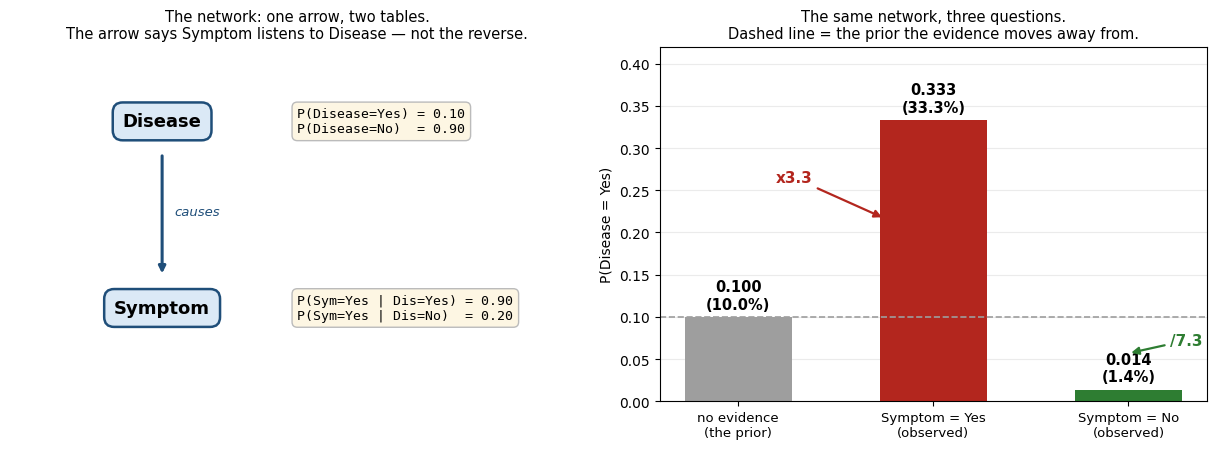

P(Disease=Yes)                 = 0.1000
P(Disease=Yes | Symptom=Yes)   = 0.3333   -> multiplied by 3.33
P(Disease=Yes | Symptom=No)    = 0.0137   -> divided by 7.30
A positive symptom is worth about 3x; a negative symptom is worth about 7x.
The evidence is far more informative when it is ABSENT - and the printed
posterior alone never tells you that.


In [5]:
# SEE the network and SEE the belief move.
# WHAT: left = the graph itself, two nodes and the tables that hang off them.
#       right = P(Disease = Yes) before any evidence, and after each possible observation.
# WHY:  a Bayesian network is a PICTURE first and a table second. Printed CPTs hide the
#       one structural fact that matters - which variable listens to which - and the
#       printed posterior hides how far the evidence actually moved the belief.
import matplotlib.pyplot as plt

# Every number below is QUERIED from the network built above - nothing is retyped.
p_prior = medical.query('Disease')['Yes']
p_pos   = medical.query('Disease', evidence={'Symptom': 'Yes'})['Yes']
p_neg   = medical.query('Disease', evidence={'Symptom': 'No'})['Yes']

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6),
                         gridspec_kw={"width_ratios": [1.05, 1.0]})

# --- Left: draw the graph, because "network" is not a figure of speech -------
ax = axes[0]
node_style = dict(boxstyle="round,pad=0.55", fc="#dbe9f6", ec="#1f4e79", lw=1.8)
ax.text(0.5, 0.80, "Disease", ha="center", va="center", fontsize=13,
        weight="bold", bbox=node_style)
ax.text(0.5, 0.30, "Symptom", ha="center", va="center", fontsize=13,
        weight="bold", bbox=node_style)
ax.annotate("", xy=(0.5, 0.385), xytext=(0.5, 0.715),
            arrowprops=dict(arrowstyle="-|>", color="#1f4e79", lw=2.2))
ax.text(0.535, 0.55, "causes", fontsize=9.5, color="#1f4e79", style="italic")
# The CPTs, written beside the node they belong to.
ax.text(0.90, 0.80, "P(Disease=Yes) = 0.10\nP(Disease=No)  = 0.90",
        fontsize=9.5, va="center", family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", fc="#fdf6e3", ec="#bbb"))
ax.text(0.90, 0.30, "P(Sym=Yes | Dis=Yes) = 0.90\nP(Sym=Yes | Dis=No)  = 0.20",
        fontsize=9.5, va="center", family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", fc="#fdf6e3", ec="#bbb"))
ax.set_xlim(0.05, 1.75); ax.set_ylim(0.05, 1.0)
ax.axis("off")
ax.set_title("The network: one arrow, two tables.\nThe arrow says Symptom listens to Disease — not the reverse.",
             fontsize=10.5)

# --- Right: what the evidence does to the belief ------------------------------
ax = axes[1]
labels = ["no evidence\n(the prior)", "Symptom = Yes\n(observed)", "Symptom = No\n(observed)"]
vals = [p_prior, p_pos, p_neg]
bars = ax.bar(range(3), vals, color=["#9e9e9e", "#b3261e", "#2e7d32"], width=0.55)
for i, v in enumerate(vals):
    ax.annotate(f"{v:.3f}\n({v:.1%})", (i, v), xytext=(0, 6),
                textcoords="offset points", ha="center", fontsize=10.5, weight="bold")
ax.axhline(p_prior, color="#9e9e9e", ls="--", lw=1.2)
# Keep the multiplier label OUTSIDE the bar - dark text on a dark bar is invisible.
ax.annotate(f"x{p_pos/p_prior:.1f}", xy=(0.75, p_prior + (p_pos - p_prior) / 2),
            xytext=(-52, 26), textcoords="offset points", fontsize=11, ha="right",
            color="#b3261e", weight="bold",
            arrowprops=dict(arrowstyle="-|>", color="#b3261e", lw=1.6))
ax.annotate(f"/{p_prior/p_neg:.1f}", xy=(2, p_neg + (p_prior - p_neg) / 2),
            xytext=(30, 6), textcoords="offset points", fontsize=11,
            color="#2e7d32", weight="bold",
            arrowprops=dict(arrowstyle="-|>", color="#2e7d32", lw=1.6))
ax.set_xticks(range(3)); ax.set_xticklabels(labels, fontsize=9.5)
ax.set_ylabel("P(Disease = Yes)")
ax.set_ylim(0, 0.42)
ax.set_title("The same network, three questions.\nDashed line = the prior the evidence moves away from.",
             fontsize=10.5)
ax.set_axisbelow(True)          # grid behind the bars, never drawn across them
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

print(f"P(Disease=Yes)                 = {p_prior:.4f}")
print(f"P(Disease=Yes | Symptom=Yes)   = {p_pos:.4f}   -> multiplied by {p_pos/p_prior:.2f}")
print(f"P(Disease=Yes | Symptom=No)    = {p_neg:.4f}   -> divided by {p_prior/p_neg:.2f}")
print("A positive symptom is worth about 3x; a negative symptom is worth about 7x.")
print("The evidence is far more informative when it is ABSENT - and the printed")
print("posterior alone never tells you that.")


### 📊 Read the figure

**Left — the network is a picture, and the direction of the arrow is the whole model.** Two nodes, one arrow, two tables. The arrow points *Disease → Symptom* because disease causes symptom, not the other way round. The tables beside each node are exactly the CPTs typed into the cell above. Everything the model knows is on this panel.

**Right — three questions, one network.** The grey bar is the prior: **P(Disease = Yes) = 0.100**, before anyone examines the patient. Observing `Symptom = Yes` raises it to **0.333** (the red bar, about **3.3×** the prior, the arrow on the left of it). Observing `Symptom = No` drops it to **0.014** (the green bar, about **7.3×** below the prior). The dashed grey line is the prior, drawn across all three so the movement is visible rather than inferred.

**What this proves:** the two observations are not equally informative. A *positive* symptom triples your suspicion and still leaves the patient more likely healthy than sick; a *negative* symptom divides it by seven and nearly settles the question. Absence of evidence is evidence of absence here — and the size of that asymmetry is visible only when the three numbers are drawn on the same axis.

---


## Part 3: More Complex Bayesian Network

Let's build a more complex network with multiple variables.


In [6]:
# Example: the classic Alarm network (Russell & Norvig)
# Structure: Burglary -> Alarm <- Earthquake ; Alarm -> JohnCalls, MaryCalls

print("=" * 60)
print("Complex Bayesian Network: Alarm System")
print("=" * 60)

alarm_net = DiscreteBayesNet("Alarm System")

alarm_net.add_variable('Burglary',   ['No', 'Yes'], cpt={(): {'No': 0.999, 'Yes': 0.001}})
alarm_net.add_variable('Earthquake', ['No', 'Yes'], cpt={(): {'No': 0.998, 'Yes': 0.002}})

# Alarm depends on both Burglary and Earthquake: cpt[(burglary, earthquake)]
alarm_net.add_variable('Alarm', ['No', 'Yes'], parents=['Burglary', 'Earthquake'],
    cpt={('No',  'No'):  {'No': 0.999, 'Yes': 0.001},
         ('No',  'Yes'): {'No': 0.71,  'Yes': 0.29},
         ('Yes', 'No'):  {'No': 0.06,  'Yes': 0.94},
         ('Yes', 'Yes'): {'No': 0.05,  'Yes': 0.95}})

alarm_net.add_variable('JohnCalls', ['No', 'Yes'], parents=['Alarm'],
    cpt={('No',):  {'No': 0.95, 'Yes': 0.05},
         ('Yes',): {'No': 0.10, 'Yes': 0.90}})

alarm_net.add_variable('MaryCalls', ['No', 'Yes'], parents=['Alarm'],
    cpt={('No',):  {'No': 0.99, 'Yes': 0.01},
         ('Yes',): {'No': 0.30, 'Yes': 0.70}})

# Inference: both neighbors call - was it a burglary?
print("\nInference: P(Burglary | JohnCalls=Yes, MaryCalls=Yes)")
result = alarm_net.query('Burglary', evidence={'JohnCalls': 'Yes', 'MaryCalls': 'Yes'})
print_dist("P(Burglary | both call):", result)

print("\nInference: P(Alarm | JohnCalls=Yes, MaryCalls=Yes)")
result_alarm = alarm_net.query('Alarm', evidence={'JohnCalls': 'Yes', 'MaryCalls': 'Yes'})
print_dist("P(Alarm | both call):", result_alarm)

print(f"\n💡 Interpretation (computed above): even with BOTH neighbors calling,")
print(f"   P(Burglary=Yes) is only {result['Yes']:.3f} — because burglaries are rare")
print(f"   (prior 0.001) and the alarm can also be triggered by earthquakes.")

Complex Bayesian Network: Alarm System
✅ Created Bayesian network: Alarm System
  ➕ Added variable: Burglary states=['No', 'Yes'] (root)
  ➕ Added variable: Earthquake states=['No', 'Yes'] (root)
  ➕ Added variable: Alarm states=['No', 'Yes'], parents=['Burglary', 'Earthquake']
  ➕ Added variable: JohnCalls states=['No', 'Yes'], parents=['Alarm']
  ➕ Added variable: MaryCalls states=['No', 'Yes'], parents=['Alarm']

Inference: P(Burglary | JohnCalls=Yes, MaryCalls=Yes)
   P(Burglary | both call):
      No    0.7158
      Yes   0.2842

Inference: P(Alarm | JohnCalls=Yes, MaryCalls=Yes)
   P(Alarm | both call):
      No    0.2393
      Yes   0.7607

💡 Interpretation (computed above): even with BOTH neighbors calling,
   P(Burglary=Yes) is only 0.284 — because burglaries are rare
   (prior 0.001) and the alarm can also be triggered by earthquakes.


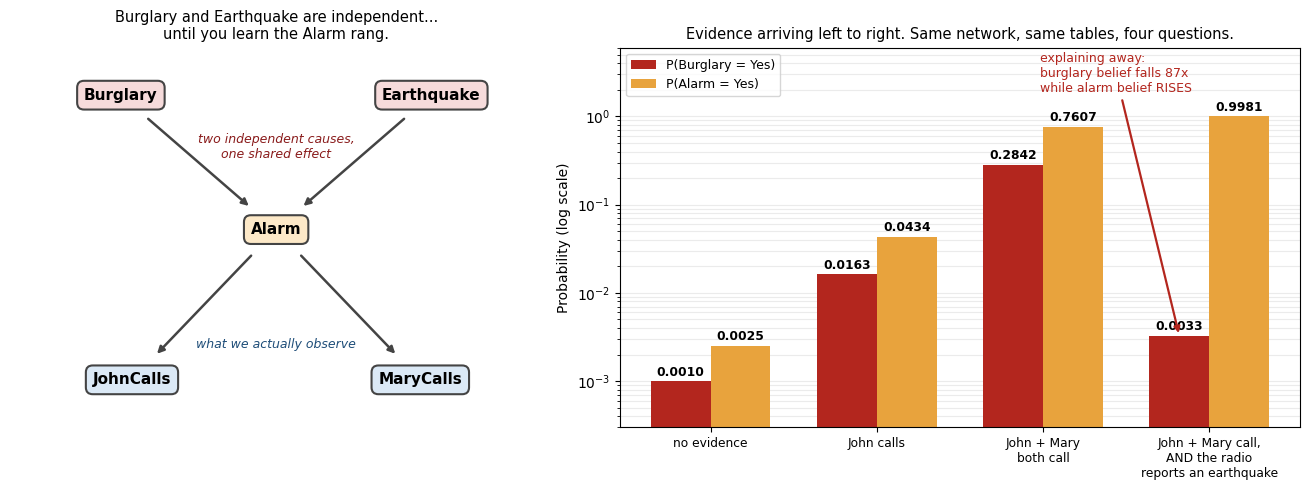

evidence                                    P(Burglary=Yes)   P(Alarm=Yes)
no evidence                                         0.00100        0.00252
John calls                                          0.01628        0.04344
John + Mary both call                               0.28417        0.76069
John + Mary call, AND the radio reports an earthquake          0.00326        0.99807

One extra true fact divides the burglary belief by 87 (0.2842 -> 0.00326),
while the alarm belief rises to 0.9981. The earthquake EXPLAINS the alarm,
so the alarm stops being evidence for a burglary. No CPT was edited to do this.


In [7]:
# SEE "explaining away" - the one thing a Bayesian network does that a table cannot.
# WHAT: left = the alarm network's graph. right = P(Burglary=Yes) and P(Alarm=Yes)
#       as evidence arrives one piece at a time, on a log axis because the belief
#       moves across three orders of magnitude.
# WHY:  the printed answer "0.284" looks like the end of the story. It is the middle.
#       Add ONE more true fact - the radio reports an earthquake - and the same network
#       collapses the burglary belief by ~87x while becoming MORE certain the alarm rang.
import numpy as np
import matplotlib.pyplot as plt

# Every value is queried from alarm_net, built in the cell above. Nothing is retyped.
scenarios = [("no evidence",                    {}),
             ("John calls",                     {'JohnCalls': 'Yes'}),
             ("John + Mary\nboth call",         {'JohnCalls': 'Yes', 'MaryCalls': 'Yes'}),
             ("John + Mary call,\nAND the radio\nreports an earthquake",
                                                {'JohnCalls': 'Yes', 'MaryCalls': 'Yes',
                                                 'Earthquake': 'Yes'})]
p_burg  = [alarm_net.query('Burglary', evidence=ev)['Yes'] for _, ev in scenarios]
p_alarm = [alarm_net.query('Alarm',    evidence=ev)['Yes'] for _, ev in scenarios]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0),
                         gridspec_kw={"width_ratios": [0.9, 1.15]})

# --- Left: the graph -----------------------------------------------------------
ax = axes[0]
pos = {"Burglary": (0.22, 0.86), "Earthquake": (0.78, 0.86), "Alarm": (0.50, 0.52),
       "JohnCalls": (0.24, 0.14), "MaryCalls": (0.76, 0.14)}
face = {"Burglary": "#f6dbdb", "Earthquake": "#f6dbdb", "Alarm": "#fde9c8",
        "JohnCalls": "#dbe9f6", "MaryCalls": "#dbe9f6"}
for name, (px, py) in pos.items():
    ax.text(px, py, name, ha="center", va="center", fontsize=11, weight="bold",
            bbox=dict(boxstyle="round,pad=0.45", fc=face[name], ec="#444", lw=1.5))
for a, b in [("Burglary", "Alarm"), ("Earthquake", "Alarm"),
             ("Alarm", "JohnCalls"), ("Alarm", "MaryCalls")]:
    ax.annotate("", xy=pos[b], xytext=pos[a],
                arrowprops=dict(arrowstyle="-|>", color="#444", lw=1.8,
                                shrinkA=26, shrinkB=26))
ax.text(0.50, 0.70, "two independent causes,\none shared effect",
        ha="center", fontsize=9, style="italic", color="#8a1c1c")
ax.text(0.50, 0.22, "what we actually observe",
        ha="center", fontsize=9, style="italic", color="#1f4e79")
ax.set_xlim(0.02, 0.98); ax.set_ylim(0.02, 0.98); ax.axis("off")
ax.set_title("Burglary and Earthquake are independent...\nuntil you learn the Alarm rang.",
             fontsize=10.5)

# --- Right: the belief cascade -------------------------------------------------
ax = axes[1]
x = np.arange(len(scenarios)); w = 0.36
ax.bar(x - w / 2, p_burg,  w, color="#b3261e", label="P(Burglary = Yes)")
ax.bar(x + w / 2, p_alarm, w, color="#e8a33d", label="P(Alarm = Yes)")
for i in range(len(x)):
    ax.annotate(f"{p_burg[i]:.4f}",  (x[i] - w / 2, p_burg[i]),  xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=8.8, weight="bold")
    ax.annotate(f"{p_alarm[i]:.4f}", (x[i] + w / 2, p_alarm[i]), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=8.8, weight="bold")
ax.set_yscale("log"); ax.set_ylim(3e-4, 6.0)
ax.set_xticks(x); ax.set_xticklabels([s for s, _ in scenarios], fontsize=8.8)
ax.set_ylabel("Probability (log scale)")
drop = p_burg[2] / p_burg[3]
ax.annotate(f"explaining away:\nburglary belief falls {drop:.0f}x\nwhile alarm belief RISES",
            xy=(3 - w / 2, p_burg[3]), xytext=(1.98, 1.9), fontsize=9.0, color="#b3261e",
            ha="left", arrowprops=dict(arrowstyle="-|>", color="#b3261e", lw=1.6))
ax.legend(loc="upper left", fontsize=9)
ax.set_axisbelow(True)   # grid behind the bars, not striped across them
ax.grid(axis="y", alpha=0.25, which="both")
ax.set_title("Evidence arriving left to right. Same network, same tables, four questions.",
             fontsize=10.5)

fig.tight_layout()
plt.show()

print(f"{'evidence':<42}{'P(Burglary=Yes)':>17}{'P(Alarm=Yes)':>15}")
for (label, _), b, a in zip(scenarios, p_burg, p_alarm):
    print(f"{label.replace(chr(10), ' '):<42}{b:>17.5f}{a:>15.5f}")
print(f"\nOne extra true fact divides the burglary belief by {drop:.0f} "
      f"({p_burg[2]:.4f} -> {p_burg[3]:.5f}),")
print(f"while the alarm belief rises to {p_alarm[3]:.4f}. The earthquake EXPLAINS the alarm,")
print("so the alarm stops being evidence for a burglary. No CPT was edited to do this.")


### 📊 Read the figure

**Left — the shape of the network is the argument.** `Burglary` and `Earthquake` both point into `Alarm`; `Alarm` points out to `JohnCalls` and `MaryCalls`. Two independent causes, one shared effect, two noisy witnesses. Burglary and Earthquake have no arrow between them: they are independent *a priori*.

**Right — read the four groups left to right.** The red bars are `P(Burglary = Yes)`; the orange bars are `P(Alarm = Yes)`. With no evidence, burglary sits at its prior **0.0010**. John calling raises it to **0.0163**. Both neighbours calling raises it to **0.2842** — this is the number the cell above printed. Then the fourth group adds one more true fact, and the red bar **collapses to 0.0033** while the orange bar **rises to 0.9981**. (The table printed under the figure gives all five digits.) The axis is logarithmic because the red bars span three orders of magnitude; a linear axis would flatten the first two groups to nothing.

**What this proves — "explaining away".** The earthquake accounts for the alarm, so the alarm stops being evidence for a burglary. Two causes that were independent before you observed the alarm become *dependent* once you have: learning one is true argues the other is false. No conditional probability table was edited to produce that; it falls out of the graph structure. This is the behaviour that makes a Bayesian network worth more than a lookup table of P(Burglary | evidence), and it is nearly impossible to see in printed numbers alone.

---


## 💬 Discuss

1. **Where did `P(Disease=Yes) = 0.10` come from?** It was typed into the cell. Suppose this network is deployed in a specialist referral clinic where 40% of arriving patients really do have the disease. Re-run the query with that prior and you get **P(Disease | Symptom=Yes) = 0.75** instead of 0.33 — the same symptom, the same test, more than double the posterior. Should a diagnostic tool ship with a fixed prior baked in, ship with a prior the site configures, or refuse to give a number until it has local data? Who is accountable for the choice?
2. **The alarm network can "explain away".** Learn that an earthquake happened, and the probability of burglary given the alarm goes *down* — even though no arrow connects Earthquake to Burglary. Nobody programmed that; it falls out of the structure. Is a model that produces conclusions its author never wrote down a strength or a hazard? What would you check before letting it drive a decision?
3. **pgmpy was not installed when this ran, so the 50-line pure-Python implementation did the work — and got the same answers**, hand-checked against Bayes' theorem in the output. When is writing your own implementation the right professional call, and when is it a liability you are handing to whoever maintains this after you? Give a concrete criterion, not "it depends".

---


## ⚠️ Where this breaks

- **Inference by enumeration is exponential, and that is what you just ran.** `DiscreteBayesNet.query` sums the joint over every combination of the hidden variables. Five binary variables: 32 terms, instant. ALARM's 37 variables: not in this universe. Real systems use variable elimination or junction trees — which is what pgmpy would have done — but there is no general escape: exact inference in Bayesian networks is NP-hard (Cooper, 1990), and so is guaranteed-accurate approximate inference (Dagum & Luby, 1993). What makes real networks tractable is their *shape*, not the algorithm.
- **Every number in this notebook was typed by a human.** A node with two binary parents needs 4 rows; with four parents, 16; with six, 64 — each estimated from data you may not have, or elicited from an expert who may be guessing. Parameter estimation, not inference, is where most Bayesian-network projects actually die.
- **The arrows assert conditional independencies, and if they are wrong the answer is confidently wrong.** Going from 31 numbers to 10 is bought by claiming that JohnCalls is independent of Burglary *given* Alarm. If John also hears the neighbour's dog whenever there is a burglar, that claim is false, and the network will still return a crisp posterior with no complaint.
- **An arrow is not a cause.** The graph is a factorisation of a joint distribution. Disease → Symptom and Symptom → Disease can represent the *same* joint distribution with different tables. Reading arrows as causal claims — and then reasoning about interventions with them — is a real and consequential error; it is exactly the distinction Pearl (1988, reference 1) exists to make precise.
- **Learning the structure from data is harder than using it.** Finding the highest-scoring DAG for a dataset is NP-hard (Chickering, 1996), which is why reference 3 is an entire survey rather than a recipe.
- **Discrete tables only.** Everything here is a finite conditional probability table. Continuous quantities — blood pressure, latency, price — need conditional Gaussians, discretisation (which throws information away) or sampling.
- **A calibrated belief is not a licence to act.** Microsoft Research's **Lumière** project (Horvitz *et al.*, UAI 1998) built Bayesian user models to infer what a user was trying to do; Horvitz has described that work as the basis for the Office Assistant that shipped in Microsoft Office. The Assistant became one of the most disliked features in software history — not because the posterior over "this user is writing a letter" was necessarily wrong, but because a well-calibrated belief says nothing about whether interrupting the user is a good idea. Inference and action are separate decisions.
- **The cheaper alternative.** One hypothesis and one piece of evidence needs no graph at all — that is the single Bayes update from notebook 01. Many features but only a class label to predict? Naive Bayes (Course 04, Unit 3) is this same network with every arrow pointing out from the class, and on real text and spam it is often good enough. Build the graph when the *dependencies between the evidence* are the thing you care about.

---


## Summary

### Key Concepts:
1. **Bayesian Networks**: Graphical models representing conditional dependencies
2. **CPDs / CPTs (Conditional Probability Distributions/Tables)**: Define relationships between variables
3. **Inference**: Compute posterior probabilities given evidence
4. **Inference by Enumeration**: The simple exact algorithm we implemented here — sum the joint distribution over hidden variables (libraries like pgmpy speed this up with Variable Elimination)

### Applications:
- Medical diagnosis
- Risk assessment
- Decision support systems
- Natural language processing

**Reference:** Course 02, Unit 3: "Building Bayesian networks using Python libraries (pgmpy)" and "Implementing inference algorithms for Bayesian networks" — implemented here in pure Python so it runs everywhere, with the equivalent pgmpy code included for environments that have the library installed.

## 📚 References

1. Pearl, J. (1988). *Probabilistic Reasoning in Intelligent Systems: Networks of Plausible Inference*. Morgan Kaufmann. (the book that established Bayesian networks)
2. Koller, D., & Friedman, N. (2009). *Probabilistic Graphical Models: Principles and Techniques*. MIT Press.
3. Kitson, N. K., Constantinou, A. C., Guo, Z., Liu, Y., & Chobtham, K. (2021). *A Survey of Bayesian Network Structure Learning*. arXiv preprint. <https://arxiv.org/abs/2109.11415>
4. Wan, G., Lu, Y., Wu, Y., Hu, M., & Li, S. (2024). *Large Language Models for Causal Discovery: Current Landscape and Future Directions*. arXiv preprint. <https://arxiv.org/abs/2402.11068> (where the arrows come from: using a language model as an imperfect domain expert when proposing the graph)
5. Zhang, Y., Zhang, Y., Kordjamshidi, P., & Cui, Z. (2025). *Bayesian Network Structure Discovery Using Large Language Models*. arXiv preprint. <https://arxiv.org/abs/2511.00574> (a model proposes the structure with no data at all, then refines it against observations)
6. Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.), Chapter 13 (Probabilistic Reasoning; the Alarm network used above comes from this book). Pearson. <https://aima.cs.berkeley.edu/>